In [1]:
import pandas as pd
import numpy as np

## EDA (Exploratory Data Analysis)

`Raw Data` → `1.Variable Identification` → `2. Univariate Analysis` → `3. Bivariate Analysis` → `4. Outlier Treatment` → `5. Missing Value Treatment` → `6. Encoding/Imputation` → `7. Feature Engineering` → `Clean Dataset` → `ML Model`

#### Basic fuction 

In [2]:
dt = pd.read_csv("raw_employee_data.csv") 

In [3]:
dt.head()

,Employee ID,Name,Domain,Department,Age,Gender,Marital Status,Location,Join Date,Salary,...,Email,Phone Number,Bonus,Attendance_Percentage,Project Count,Remote Work,Manager Name,Education Level,Last Review Date,Employee Status
0,EMP5368,Sahil Bhalla,DevOps,NaN,27,Male,NaN,Ahmedabad,"Sep 07, 2024",3%0000,...,sahilbhalla54@gmail.com,+91-8295881247,NaN,96.0%,8,Yes,Jane Agarwal,PhD,26.04.2024,Resigned
1,EMP7787,Shreya Madan*,NLP,Support,53,female,Single,Delhi,2015/02/07,8000,...,shreyamadan82@company.com,09033972852,750%0,85.1%,10,no,Kabir Taneja,Bachelors,2024/02/02,Terminated
2,EMP8856,Varun Kohli,DevOps,NaN,37 years,female,S,Banglore,2021-09-19,NaN,...,varunkohli80@outlook.com,(+91) 1152429926,1000,91.7pct,1+,No,Noah Hooda^,Bachelors,21-Apr-2024,Active
3,EMP1188,Nina Kohli,NLP,Operations,65' yr,f,Divorced,Hyderabad,2018-01-28,12000,...,ninakohli66@company.com,NaN,1500^0,84 %,10,YES,ava rastogi,Masters,16.06.2025,Terminated
4,EMP3125,Hannah Acharya,devops,Finance,61yr,male,Divorced,Mumbai,12-Jul-2021,5$000,...,hannahacharya60@yahoo.in,NaN,1000,63.0%,2,yes,Pari Chhabra,M.Tech/MBA,"Mar 05, 2025",Resigned


In [4]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 10008 entries, 0 to 10007
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Employee ID            10006 non-null  str  
 1   Name                   10006 non-null  str  
 2   Domain                 10006 non-null  str  
 3   Department             9200 non-null   str  
 4   Age                    8617 non-null   str  
 5   Gender                 9048 non-null   str  
 6   Marital Status         8782 non-null   str  
 7   Location               8546 non-null   str  
 8   Join Date              10006 non-null  str  
 9   Salary                 9408 non-null   str  
 10  Exp                    8443 non-null   str  
 11  Performance Rating     8178 non-null   str  
 12  Email                  9030 non-null   str  
 13  Phone Number           8811 non-null   str  
 14  Bonus                  7959 non-null   str  
 15  Attendance_Percentage  8536 non-null   str  
 1

In [5]:
dt.columns

Index(['Employee ID', 'Name', 'Domain', 'Department', 'Age', 'Gender',
       'Marital Status', 'Location', 'Join Date', 'Salary', 'Exp',
       'Performance Rating', 'Email', 'Phone Number', 'Bonus',
       'Attendance_Percentage', 'Project Count', 'Remote Work', 'Manager Name',
       'Education Level', 'Last Review Date', 'Employee Status'],
      dtype='str')

In [6]:
dt.shape

(10008, 22)

#### Standardize column names.
- column names must lower case
- Space not allow in column names use '_' 
- allow only a - z

In [7]:
dt.columns

Index(['Employee ID', 'Name', 'Domain', 'Department', 'Age', 'Gender',
       'Marital Status', 'Location', 'Join Date', 'Salary', 'Exp',
       'Performance Rating', 'Email', 'Phone Number', 'Bonus',
       'Attendance_Percentage', 'Project Count', 'Remote Work', 'Manager Name',
       'Education Level', 'Last Review Date', 'Employee Status'],
      dtype='str')

In [8]:
dt.columns = dt.columns.str.lower().str.strip().str.replace(' ','_')

In [9]:
dt.columns

Index(['employee_id', 'name', 'domain', 'department', 'age', 'gender',
       'marital_status', 'location', 'join_date', 'salary', 'exp',
       'performance_rating', 'email', 'phone_number', 'bonus',
       'attendance_percentage', 'project_count', 'remote_work', 'manager_name',
       'education_level', 'last_review_date', 'employee_status'],
      dtype='str')

In [10]:
len( dt.columns )

22

In [11]:
print(f'Columns = {dt.shape[1]},\nRows = {dt.shape[0]}')

Columns = 22,
Rows = 10008


In [12]:
dt.columns.to_list()

['employee_id',
 'name',
 'domain',
 'department',
 'age',
 'gender',
 'marital_status',
 'location',
 'join_date',
 'salary',
 'exp',
 'performance_rating',
 'email',
 'phone_number',
 'bonus',
 'attendance_percentage',
 'project_count',
 'remote_work',
 'manager_name',
 'education_level',
 'last_review_date',
 'employee_status']

#### clean rows 
- remove letter form numrical columns
- remove special key from unwanted columns (decimal points only)

In [13]:
dt.head()

,employee_id,name,domain,department,age,gender,marital_status,location,join_date,salary,...,email,phone_number,bonus,attendance_percentage,project_count,remote_work,manager_name,education_level,last_review_date,employee_status
0,EMP5368,Sahil Bhalla,DevOps,NaN,27,Male,NaN,Ahmedabad,"Sep 07, 2024",3%0000,...,sahilbhalla54@gmail.com,+91-8295881247,NaN,96.0%,8,Yes,Jane Agarwal,PhD,26.04.2024,Resigned
1,EMP7787,Shreya Madan*,NLP,Support,53,female,Single,Delhi,2015/02/07,8000,...,shreyamadan82@company.com,09033972852,750%0,85.1%,10,no,Kabir Taneja,Bachelors,2024/02/02,Terminated
2,EMP8856,Varun Kohli,DevOps,NaN,37 years,female,S,Banglore,2021-09-19,NaN,...,varunkohli80@outlook.com,(+91) 1152429926,1000,91.7pct,1+,No,Noah Hooda^,Bachelors,21-Apr-2024,Active
3,EMP1188,Nina Kohli,NLP,Operations,65' yr,f,Divorced,Hyderabad,2018-01-28,12000,...,ninakohli66@company.com,NaN,1500^0,84 %,10,YES,ava rastogi,Masters,16.06.2025,Terminated
4,EMP3125,Hannah Acharya,devops,Finance,61yr,male,Divorced,Mumbai,12-Jul-2021,5$000,...,hannahacharya60@yahoo.in,NaN,1000,63.0%,2,yes,Pari Chhabra,M.Tech/MBA,"Mar 05, 2025",Resigned


#### Category Data Cleaning

In [14]:
category_data = ['employee_id','name','domain','department','gender','marital_status','location','remote_work','manager_name','education_level','employee_status']
for i in category_data:
    dt[i] = dt[i].str.replace(' ','_')
    dt[i] = dt[i].str.replace(r'\W', '', regex=True)
    dt[i] = dt[i].str.replace('_', ' ')
    dt[i] = dt[i].str.strip() 

In [15]:
dt.head()

,employee_id,name,domain,department,age,gender,marital_status,location,join_date,salary,...,email,phone_number,bonus,attendance_percentage,project_count,remote_work,manager_name,education_level,last_review_date,employee_status
0,EMP5368,Sahil Bhalla,DevOps,NaN,27,Male,NaN,Ahmedabad,"Sep 07, 2024",3%0000,...,sahilbhalla54@gmail.com,+91-8295881247,NaN,96.0%,8,Yes,Jane Agarwal,PhD,26.04.2024,Resigned
1,EMP7787,Shreya Madan,NLP,Support,53,female,Single,Delhi,2015/02/07,8000,...,shreyamadan82@company.com,09033972852,750%0,85.1%,10,no,Kabir Taneja,Bachelors,2024/02/02,Terminated
2,EMP8856,Varun Kohli,DevOps,NaN,37 years,female,S,Banglore,2021-09-19,NaN,...,varunkohli80@outlook.com,(+91) 1152429926,1000,91.7pct,1+,No,Noah Hooda,Bachelors,21-Apr-2024,Active
3,EMP1188,Nina Kohli,NLP,Operations,65' yr,f,Divorced,Hyderabad,2018-01-28,12000,...,ninakohli66@company.com,NaN,1500^0,84 %,10,YES,ava rastogi,Masters,16.06.2025,Terminated
4,EMP3125,Hannah Acharya,devops,Finance,61yr,male,Divorced,Mumbai,12-Jul-2021,5$000,...,hannahacharya60@yahoo.in,NaN,1000,63.0%,2,yes,Pari Chhabra,MTechMBA,"Mar 05, 2025",Resigned


#### Numberical Data Cleaning

In [16]:
#str.replace(r'\D', '', regex=True)
#str.extract(r'(\d+)', expand=False)


In [17]:
numberical_data = ['age','salary','exp','bonus','project_count']
for i in numberical_data:
    dt[i] = dt[i].str.extract(r'(\d+)', expand=False)
    dt[i] = dt[i].str.strip() 

In [18]:
#other numberical data
dt['attendance_percentage'] = dt['attendance_percentage'].str.strip().str.lower()
dt['attendance_percentage'] = dt['attendance_percentage'].str.replace('%','').str.replace('pct', '').str.replace('percent', '')


dt['performance_rating'] = dt['performance_rating'].astype(str).str.strip().str.lower()
dt['performance_rating'] = dt['performance_rating'].str.replace('/5','', regex=False)
dt['performance_rating'] = dt['performance_rating'].str.replace(' stars','', regex=False)
dt['performance_rating'] = dt['performance_rating'].str.replace(r'[^0-9.]','', regex=True)
dt['performance_rating'] = pd.to_numeric(dt['performance_rating'], errors='coerce')

dt['performance_rating'] = dt['performance_rating'].apply(
     lambda x: round(x/20, 1) if x > 5 else x
 )

#### Date Data Cleaning

In [19]:
date_data = ['last_review_date','join_date']
for i in date_data:
    dt[i] = pd.to_datetime(dt[i], format='mixed', dayfirst=True, errors='coerce')


In [20]:
dt.head()

,employee_id,name,domain,department,age,gender,marital_status,location,join_date,salary,...,email,phone_number,bonus,attendance_percentage,project_count,remote_work,manager_name,education_level,last_review_date,employee_status
0,EMP5368,Sahil Bhalla,DevOps,NaN,27,Male,NaN,Ahmedabad,2024-09-07,3,...,sahilbhalla54@gmail.com,+91-8295881247,NaN,96.0,8,Yes,Jane Agarwal,PhD,2024-04-26,Resigned
1,EMP7787,Shreya Madan,NLP,Support,53,female,Single,Delhi,2015-07-02,8000,...,shreyamadan82@company.com,09033972852,750,85.1,10,no,Kabir Taneja,Bachelors,2024-02-02,Terminated
2,EMP8856,Varun Kohli,DevOps,NaN,37,female,S,Banglore,2021-09-19,NaN,...,varunkohli80@outlook.com,(+91) 1152429926,1000,91.7,1,No,Noah Hooda,Bachelors,2024-04-21,Active
3,EMP1188,Nina Kohli,NLP,Operations,65,f,Divorced,Hyderabad,2018-01-28,12000,...,ninakohli66@company.com,NaN,1500,84,10,YES,ava rastogi,Masters,2025-06-16,Terminated
4,EMP3125,Hannah Acharya,devops,Finance,61,male,Divorced,Mumbai,2021-07-12,5,...,hannahacharya60@yahoo.in,NaN,1000,63.0,2,yes,Pari Chhabra,MTechMBA,2025-03-05,Resigned


#### Other cleaning

In [ ]:
for i in dt.columns:
    if clean_dt[i].nunique() < 15:
        print(f'{i} = {list(clean_dt[i].unique())}\n')

In [21]:
def dom(x):
    x = str(x)
    if x.lower().strip() == 'dataanalyst': return      'Data Analyst'
    if x.lower().strip() == 'analytics': return        'Analytics'
    if x.lower().strip() == 'machinelearning': return  'Machine Learning'
    if x.lower().strip() == 'cloudengineering': return 'Cloud Engineering'
    if x.lower().strip() == 'datascience': return      'Data Science'
    if x.lower().strip() == 'testing': return          'Testing'
    if x.lower().strip() == 'statistics': return       'Statistics'
    if x.lower().strip() == 'webdevelopment': return   'Web Development'
    if x.lower().strip() == 'devops': return           'DevOps'
    if x.lower().strip() == 'nlp': return              'Natural Language Processing'

dt['domain'] = dt['domain'].apply(lambda x: dom(x))

In [22]:
def dep(x):
    x = str(x)
    if x.lower().strip() in ['engineering','engineeringdept']: return 'Engineering Dept'
    if x.lower().strip() in ['finance','financedept']: return 'Finance Dept'
    if x.lower().strip() in ['hr','hrdept']: return  'HR Dept'
    if x.lower().strip() in ['sales','salesdept']: return 'Sales Dept'
    if x.lower().strip() in ['support','supportdept']: return 'Support Dept'
    if x.lower().strip() in ['operations','operationsdept']: return 'Operations Dept'
    if x.lower().strip() in ['marketing','marketingdept']: return 'Marketing Dept'

dt['department'] = dt['department'].apply(lambda x: dep(x))

In [23]:
def sex(x):
    x = str(x)
    if x.lower().strip() in ['m', 'male']: return 'Male'
    if x.lower().strip() in ['f', 'female']: return 'Female'

dt['gender'] = dt['gender'].apply(lambda x: sex(x))

In [24]:
def mag(x):
    x = str(x)
    if x.lower().strip() in ['s', 'single']:    return 'Single'
    if x.lower().strip() in ['m', 'married']:   return 'Married'
    if x.lower().strip() in ['d', 'divorced']:  return 'Divorced'
        
dt['marital_status'] = dt['marital_status'].apply(lambda x: mag(x))

In [25]:
def edu(x):
    x = str(x)
    if x.lower().strip() == 'phd':    return 'PhD'
    if x.lower().strip() == 'diploma':   return 'Diploma'
    if x.lower().strip() == 'masters':  return 'Masters'
    if x.lower().strip() == 'phd':    return 'PhD'
    if x.lower().strip() == 'mtechmba':   return 'M.Tech / MBA'
    if x.lower().strip() == 'btechbe':  return 'B.Tech / BE'

        
dt['education_level'] = dt['education_level'].apply(lambda x: edu(x))

In [26]:
def emp(x):
    x = str(x)
    if x.lower().strip() == 'active':      return 'Active'
    if x.lower().strip() == 'resigned':    return 'Resigned'
    if x.lower().strip() == 'terminated':  return 'Terminated'
       
dt['employee_status'] = dt['employee_status'].apply(lambda x: emp(x))

In [27]:
def rew(x):
    x = str(x)
    if x.lower().strip() in ['yes', 'y']: return 'Yes'
    if x.lower().strip() in ['no',  'n']: return 'No'
        
dt['remote_work'] = dt['remote_work'].apply(lambda x: rew(x))

In [ ]:
for i in dt.columns:
    if clean_dt[i].nunique() < 15:
        print(f'{i} = {list(clean_dt[i].unique())}\n')

In [28]:
dt.head()

,employee_id,name,domain,department,age,gender,marital_status,location,join_date,salary,...,email,phone_number,bonus,attendance_percentage,project_count,remote_work,manager_name,education_level,last_review_date,employee_status
0,EMP5368,Sahil Bhalla,DevOps,NaN,27,Male,NaN,Ahmedabad,2024-09-07,3,...,sahilbhalla54@gmail.com,+91-8295881247,NaN,96.0,8,Yes,Jane Agarwal,PhD,2024-04-26,Resigned
1,EMP7787,Shreya Madan,Natural Language Processing,Support Dept,53,Female,Single,Delhi,2015-07-02,8000,...,shreyamadan82@company.com,09033972852,750,85.1,10,No,Kabir Taneja,NaN,2024-02-02,Terminated
2,EMP8856,Varun Kohli,DevOps,NaN,37,Female,Single,Banglore,2021-09-19,NaN,...,varunkohli80@outlook.com,(+91) 1152429926,1000,91.7,1,No,Noah Hooda,NaN,2024-04-21,Active
3,EMP1188,Nina Kohli,Natural Language Processing,Operations Dept,65,Female,Divorced,Hyderabad,2018-01-28,12000,...,ninakohli66@company.com,NaN,1500,84,10,Yes,ava rastogi,Masters,2025-06-16,Terminated
4,EMP3125,Hannah Acharya,DevOps,Finance Dept,61,Male,Divorced,Mumbai,2021-07-12,5,...,hannahacharya60@yahoo.in,NaN,1000,63.0,2,Yes,Pari Chhabra,M.Tech / MBA,2025-03-05,Resigned


### (EDA)Imputation / Encoding
Convert categorical → numerical.

In [29]:
dt.dtypes

employee_id                         str
name                                str
domain                              str
department                          str
age                                 str
gender                              str
marital_status                      str
location                            str
join_date                datetime64[us]
salary                              str
exp                                 str
performance_rating              float64
email                               str
phone_number                        str
bonus                               str
attendance_percentage               str
project_count                       str
remote_work                         str
manager_name                        str
education_level                     str
last_review_date         datetime64[us]
employee_status                     str
dtype: object

In [30]:
for i in dt.columns:
    if i in ['performance_rating','attendance_percentage','age','salary','exp','bonus','project_count']:
        dt[i] = dt[i].astype(float)

In [31]:
for i in dt.columns:
    if i in ['employee_id','name','domain','department','gender','marital_status','location','email','remote_work','manager_name','education_level','employee_status']:
        dt[i] = dt[i].astype('category')

In [32]:
dt.dtypes

employee_id                    category
name                           category
domain                         category
department                     category
age                             float64
gender                         category
marital_status                 category
location                       category
join_date                datetime64[us]
salary                          float64
exp                             float64
performance_rating              float64
email                          category
phone_number                        str
bonus                           float64
attendance_percentage           float64
project_count                   float64
remote_work                    category
manager_name                   category
education_level                category
last_review_date         datetime64[us]
employee_status                category
dtype: object

### (EDA) Missing Value Treatment

In [33]:
dt.head()

,employee_id,name,domain,department,age,gender,marital_status,location,join_date,salary,...,email,phone_number,bonus,attendance_percentage,project_count,remote_work,manager_name,education_level,last_review_date,employee_status
0,EMP5368,Sahil Bhalla,DevOps,NaN,27.0,Male,NaN,Ahmedabad,2024-09-07,3.0,...,sahilbhalla54@gmail.com,+91-8295881247,NaN,96.0,8.0,Yes,Jane Agarwal,PhD,2024-04-26,Resigned
1,EMP7787,Shreya Madan,Natural Language Processing,Support Dept,53.0,Female,Single,Delhi,2015-07-02,8000.0,...,shreyamadan82@company.com,09033972852,750.0,85.1,10.0,No,Kabir Taneja,NaN,2024-02-02,Terminated
2,EMP8856,Varun Kohli,DevOps,NaN,37.0,Female,Single,Banglore,2021-09-19,NaN,...,varunkohli80@outlook.com,(+91) 1152429926,1000.0,91.7,1.0,No,Noah Hooda,NaN,2024-04-21,Active
3,EMP1188,Nina Kohli,Natural Language Processing,Operations Dept,65.0,Female,Divorced,Hyderabad,2018-01-28,12000.0,...,ninakohli66@company.com,NaN,1500.0,84.0,10.0,Yes,ava rastogi,Masters,2025-06-16,Terminated
4,EMP3125,Hannah Acharya,DevOps,Finance Dept,61.0,Male,Divorced,Mumbai,2021-07-12,5.0,...,hannahacharya60@yahoo.in,NaN,1000.0,63.0,2.0,Yes,Pari Chhabra,M.Tech / MBA,2025-03-05,Resigned


In [34]:
dt.isnull().sum()

employee_id                 2
name                        2
domain                      2
department               1726
age                      1391
gender                    960
marital_status           1226
location                 1462
join_date                   2
salary                    600
exp                      1565
performance_rating       1830
email                     978
phone_number             1197
bonus                    2049
attendance_percentage    1472
project_count             988
remote_work               997
manager_name             1188
education_level          2750
last_review_date            2
employee_status           841
dtype: int64

In [35]:
dt = dt.dropna(subset=['employee_id'])

In [36]:
for i in ['department','gender','location','marital_status','remote_work','education_level','employee_status']:
    dt[i] = dt[i].fillna(dt[i].mode()[0])
    

In [37]:
for i in ['email','phone_number','manager_name']:
    dt[i] = dt[i].apply(lambda x: 'Not Entered By User' if pd.isna(x) else x)


In [38]:
for i in ['age','salary','exp','performance_rating','bonus','attendance_percentage','project_count']:
    dt[i] = dt[i].fillna( dt[i].mean() )
    

In [39]:
for i in ['join_date','last_review_date']:
    dt[i] = dt[i].fillna( 0 )

In [84]:
print(any(clean_dt.duplicated()))
#if True
#dt.drop_duplicates()

False


In [40]:
dt.isnull().sum()

employee_id              0
name                     0
domain                   0
department               0
age                      0
gender                   0
marital_status           0
location                 0
join_date                0
salary                   0
exp                      0
performance_rating       0
email                    0
phone_number             0
bonus                    0
attendance_percentage    0
project_count            0
remote_work              0
manager_name             0
education_level          0
last_review_date         0
employee_status          0
dtype: int64

In [41]:
dt.to_csv('clean_employee_data.csv')

### (EDA) Variable Identification

- **independent variables (X)**
  - **X** → Age, Department, Experience
- **dependent variable (Y)**
  - **Y** → Salary (target for prediction)

### (EDA) Univariate Analysis
- Study each variable individually.
- Tools: histograms, boxplots, frequency counts.
- Purpose: detect distribution, skewness, outliers.

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
clean_dt = pd.read_csv('clean_employee_data.csv')

In [44]:
%matplotlib inline
sns.set(style="darkgrid")

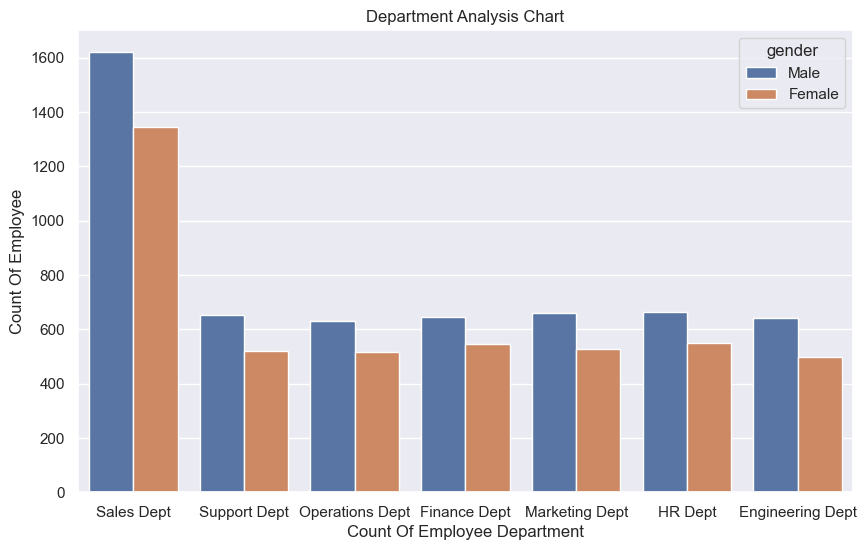

In [45]:
plt.figure(figsize=(10, 6)) 
sns.countplot(x='department', data = clean_dt,hue='gender')
plt.title('Department Analysis Chart')
plt.ylabel('Count Of Employee')
plt.xlabel('Count Of Employee Department')
plt.show()

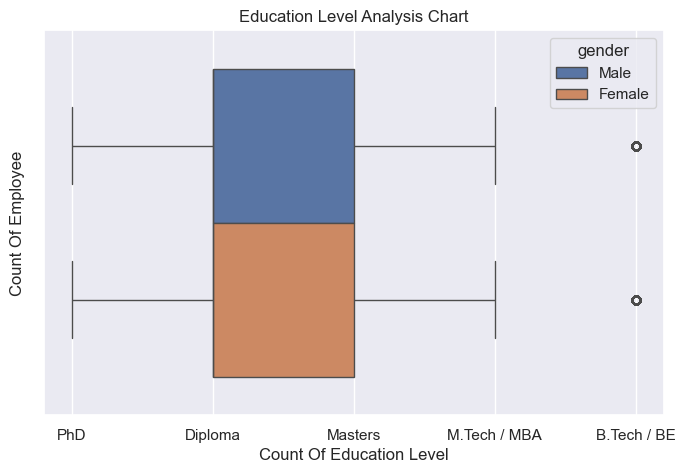

In [46]:
plt.figure(figsize=(8, 5)) 
sns.boxplot(x='education_level', data = clean_dt,hue='gender')
plt.title('Education Level Analysis Chart')
plt.ylabel('Count Of Employee')
plt.xlabel('Count Of Education Level')
plt.show()

<Figure size 1000x500 with 0 Axes>

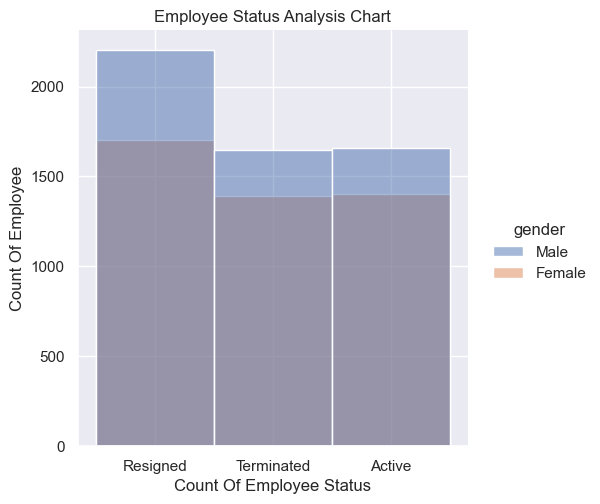

In [47]:
plt.figure(figsize=(10, 5)) 
sns.displot(x='employee_status', data = clean_dt,hue='gender')
plt.title('Employee Status Analysis Chart')
plt.ylabel('Count Of Employee')
plt.xlabel('Count Of Employee Status')
plt.show()

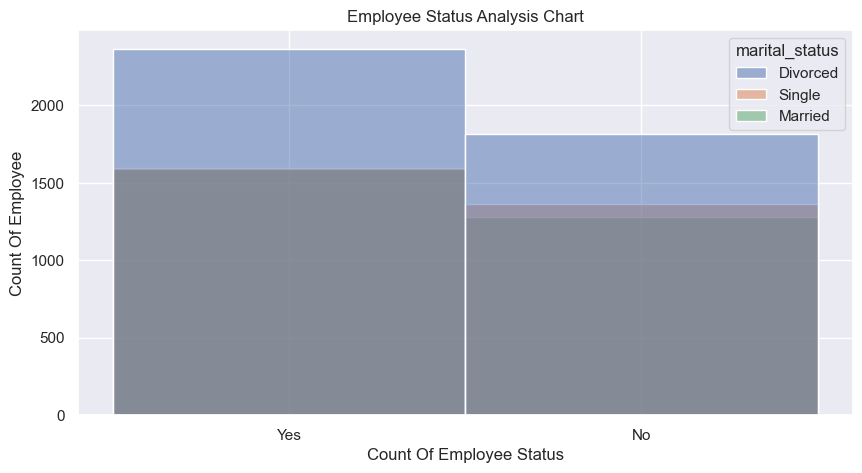

In [48]:
plt.figure(figsize=(10, 5)) 
sns.histplot(x='remote_work', data = clean_dt, hue='marital_status')
plt.title('Employee Status Analysis Chart')
plt.ylabel('Count Of Employee')
plt.xlabel('Count Of Employee Status')
plt.show()

In [49]:
print(clean_dt['gender'].value_counts())
print(clean_dt['marital_status'].value_counts())
print(clean_dt['remote_work'].value_counts())
print(clean_dt['employee_status'].value_counts())

gender
Male      5509
Female    4497
Name: count, dtype: int64
marital_status
Divorced    4182
Single      2958
Married     2866
Name: count, dtype: int64
remote_work
Yes    5553
No     4453
Name: count, dtype: int64
employee_status
Resigned      3907
Active        3061
Terminated    3038
Name: count, dtype: int64


### (EDA) Bivariate Analysis
- Study relationships between two variables.
- Tools: scatterplots, correlation matrix.
- Purpose: find linear/non-linear relationships.

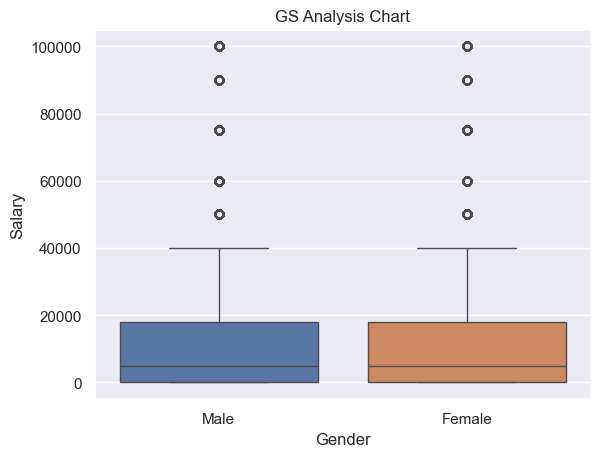

In [50]:
sns.boxplot(x = 'gender',y = 'salary',data=clean_dt,hue='gender')
plt.title('GS Analysis Chart')
plt.ylabel('Salary')
plt.xlabel('Gender')
plt.show()

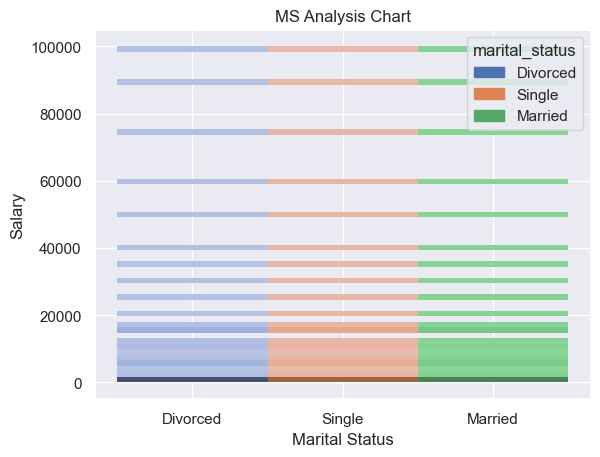

In [51]:
sns.histplot(x = 'marital_status',y = 'salary',data=clean_dt,hue='marital_status')
plt.title('MS Analysis Chart')
plt.ylabel('Salary')
plt.xlabel('Marital Status')
plt.show()

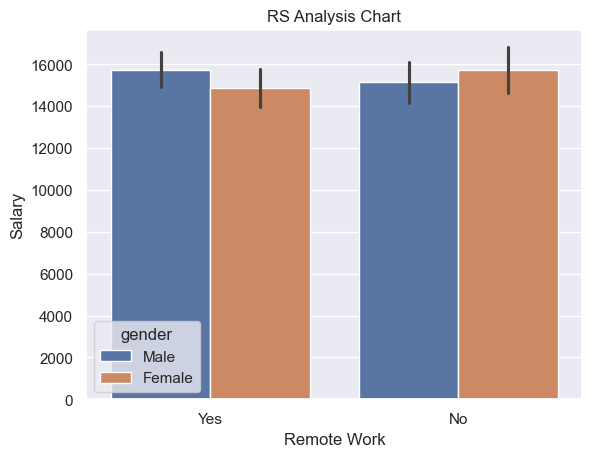

In [52]:
sns.barplot(x ='remote_work',y = 'salary',data=clean_dt,hue='gender')
plt.title('RS Analysis Chart')
plt.ylabel('Salary')
plt.xlabel('Remote Work')
plt.show()

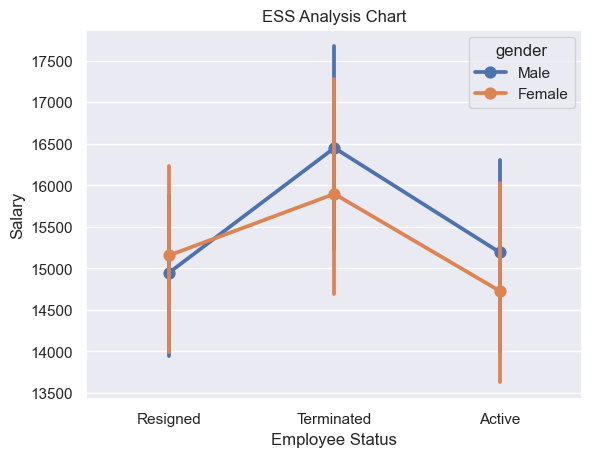

In [53]:
sns.pointplot(x ='employee_status',y = 'salary',data=clean_dt,hue='gender')
plt.title('ESS Analysis Chart')
plt.ylabel('Salary')
plt.xlabel('Employee Status')
plt.show()

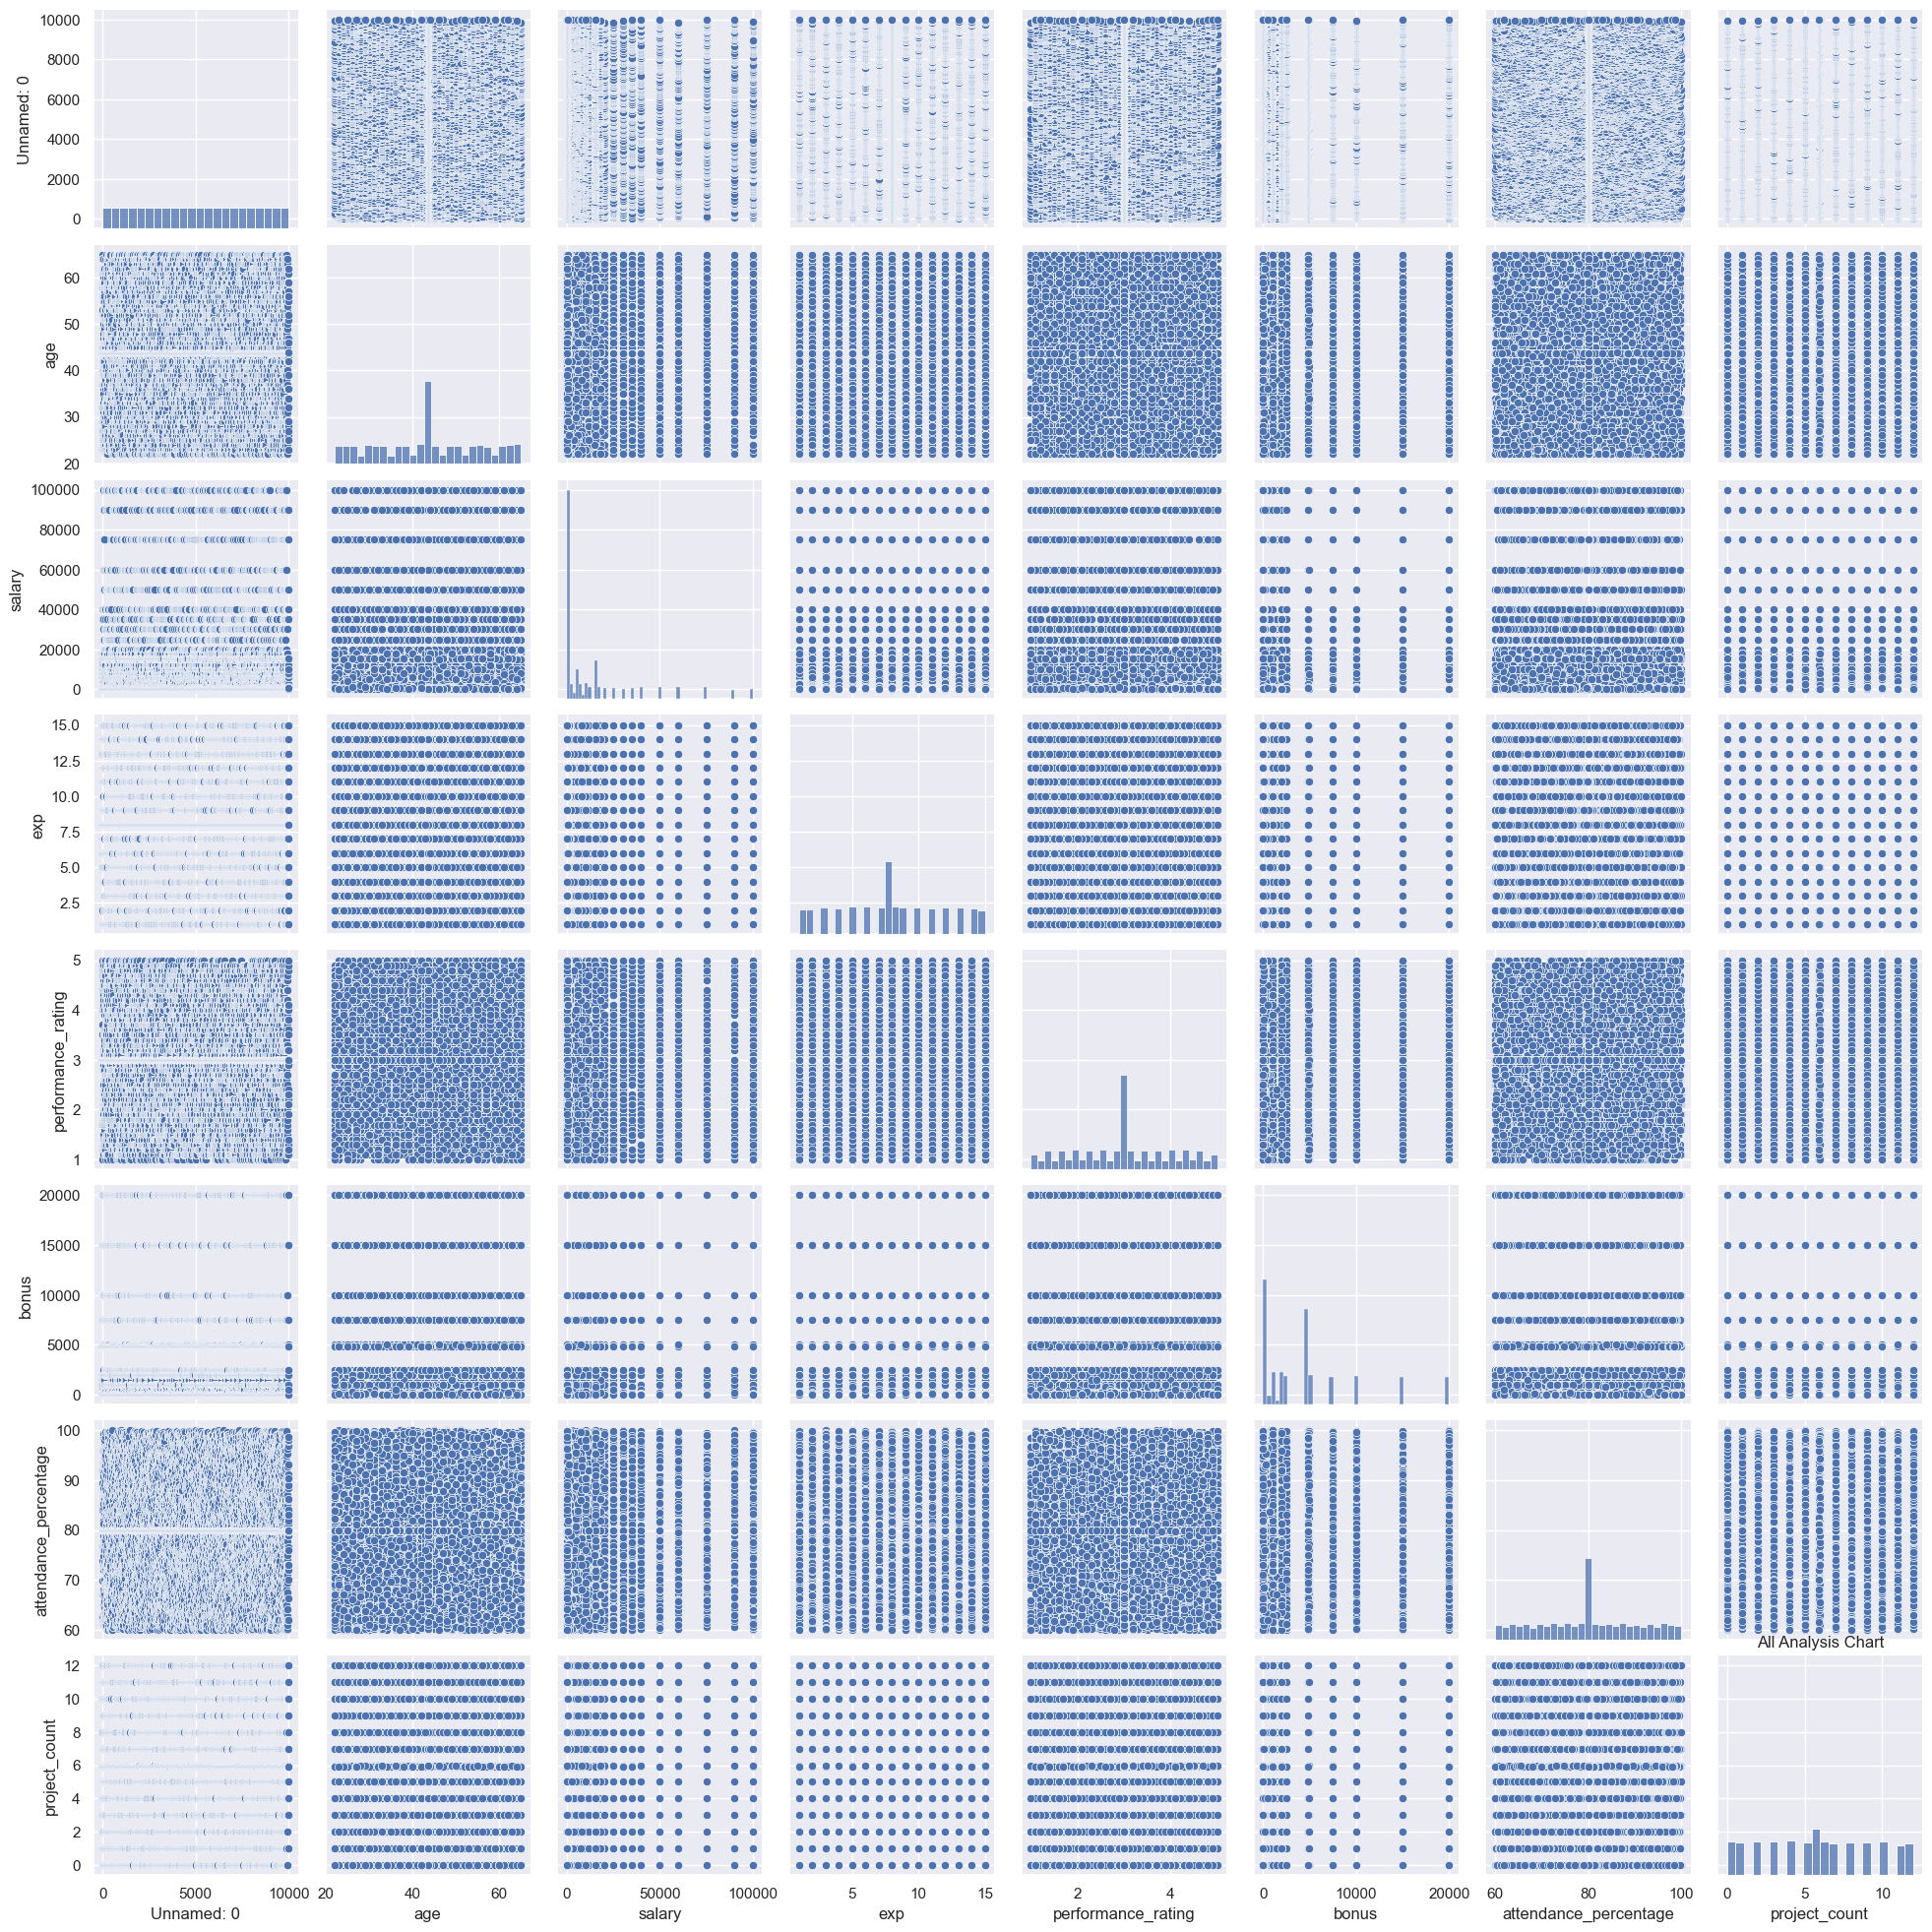

In [54]:
sns.pairplot( clean_dt )
plt.title('All Analysis Chart')
plt.show()

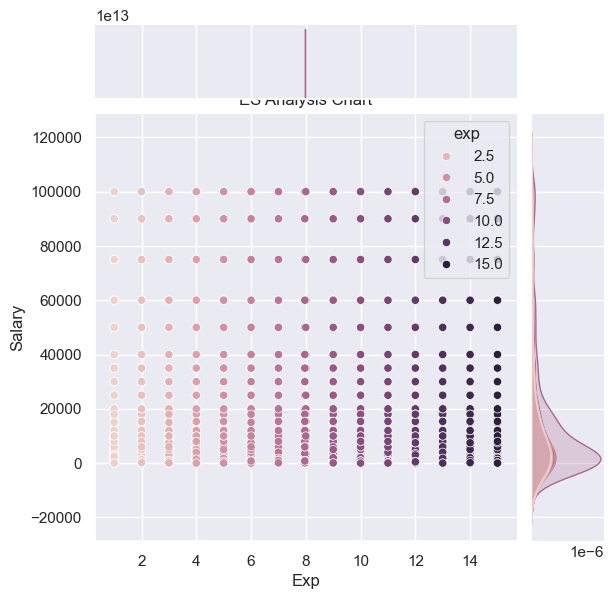

In [59]:
sns.jointplot(x ='exp',y = 'salary',data=clean_dt,hue='exp')
plt.title('ES Analysis Chart')
plt.ylabel('Salary')
plt.xlabel('Exp')
plt.show()

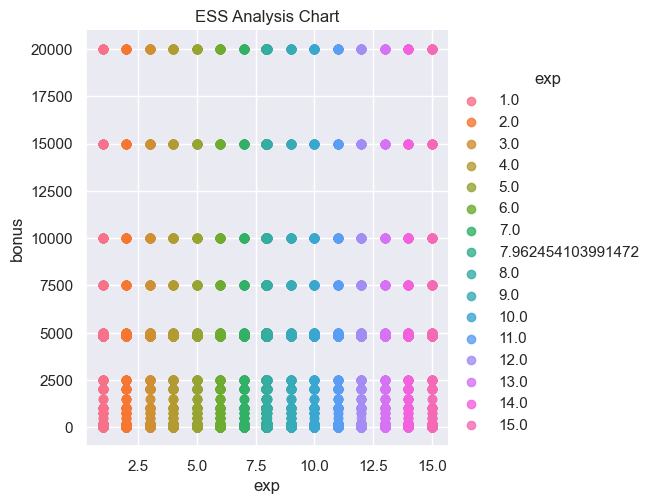

In [56]:
sns.lmplot(x ='exp',y = 'bonus',data=clean_dt,hue='exp',fit_reg=False)
plt.title('ESS Analysis Chart')
plt.ylabel('bonus')
plt.xlabel('exp')
plt.show()

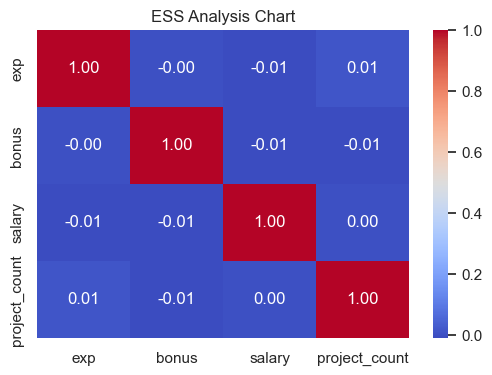

In [64]:
# correlation matrix of numeric columns
corr = clean_dt[['exp','bonus','salary','project_count']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("ESS Analysis Chart")
plt.show()

<Axes: xlabel='exp'>

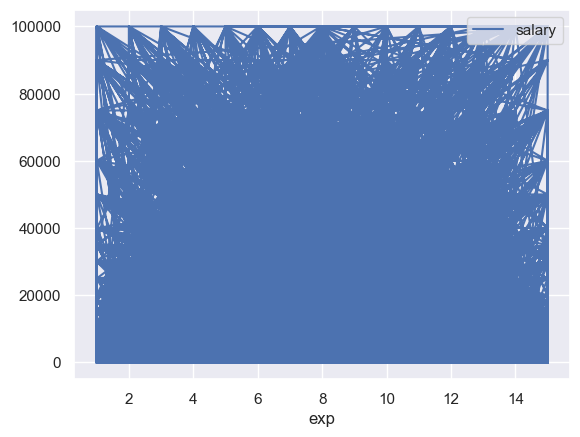

In [96]:
clean_dt.plot(x = 'exp', y = 'salary')

## Descriptive Statistics

In [98]:
clean_dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 10006 entries, 0 to 10005
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             10006 non-null  int64  
 1   employee_id            10006 non-null  str    
 2   name                   10006 non-null  str    
 3   domain                 10006 non-null  str    
 4   department             10006 non-null  str    
 5   age                    10006 non-null  float64
 6   gender                 10006 non-null  str    
 7   marital_status         10006 non-null  str    
 8   location               10006 non-null  str    
 9   join_date              10006 non-null  str    
 10  salary                 10006 non-null  float64
 11  exp                    10006 non-null  float64
 12  performance_rating     10006 non-null  float64
 13  email                  10006 non-null  str    
 14  phone_number           10006 non-null  str    
 15  bonus        

In [99]:
clean_dt.describe()

,Unnamed: 0,age,salary,exp,performance_rating,bonus,attendance_percentage,project_count
count,10006.000000,10006.000000,10006.000000,10006.000000,10006.000000,10006.000000,10006.000000,10006.000000
mean,5003.490106,43.627713,15370.519452,7.962454,3.001027,4806.357080,80.014984,5.929601
std,2889.428168,11.820182,24110.872091,3.909254,1.045951,5492.662489,10.629020,3.538272
min,0.000000,22.000000,1.000000,1.000000,1.000000,0.000000,60.000000,0.000000
25%,2501.250000,34.000000,60.000000,5.000000,2.200000,200.000000,72.000000,3.000000
50%,5003.500000,43.627713,5000.000000,7.962454,3.001027,4806.357080,80.014984,5.929601
75%,7505.750000,53.000000,18000.000000,11.000000,3.800000,5000.000000,88.100000,9.000000
max,10007.000000,65.000000,100000.000000,15.000000,5.000000,20000.000000,100.000000,12.000000


In [101]:
clean_dt.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10006.0,5003.490106,2889.428168,0.0,2501.25,5003.500000,7505.75,10007.0
age,10006.0,43.627713,11.820182,22.0,34.00,43.627713,53.00,65.0
salary,10006.0,15370.519452,24110.872091,1.0,60.00,5000.000000,18000.00,100000.0
exp,10006.0,7.962454,3.909254,1.0,5.00,7.962454,11.00,15.0
performance_rating,10006.0,3.001027,1.045951,1.0,2.20,3.001027,3.80,5.0
bonus,10006.0,4806.357080,5492.662489,0.0,200.00,4806.357080,5000.00,20000.0
attendance_percentage,10006.0,80.014984,10.629020,60.0,72.00,80.014984,88.10,100.0
project_count,10006.0,5.929601,3.538272,0.0,3.00,5.929601,9.00,12.0


In [102]:
clean_dt.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,10006.0,NaN,NaN,NaN,5003.490106,2889.428168,0.0,2501.25,5003.5,7505.75,10007.0
employee_id,10006,10000,EMP9517,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,10006,9786,Liam Wilson,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
domain,10006,10,Data Science,1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,10006,7,Sales Dept,2965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10006.0,NaN,NaN,NaN,43.627713,11.820182,22.0,34.0,43.627713,53.0,65.0
gender,10006,2,Male,5509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,10006,3,Divorced,4182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,10006,11,Mumbai,2582,NaN,NaN,NaN,NaN,NaN,NaN,NaN
join_date,10006,3681,2014-07-29,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
clean_dt.isnull().any()

Unnamed: 0               False
employee_id              False
name                     False
domain                   False
department               False
age                      False
gender                   False
marital_status           False
location                 False
join_date                False
salary                   False
exp                      False
performance_rating       False
email                    False
phone_number             False
bonus                    False
attendance_percentage    False
project_count            False
remote_work              False
manager_name             False
education_level          False
last_review_date         False
employee_status          False
dtype: bool

In [104]:
clean_dt.columns

Index(['Unnamed: 0', 'employee_id', 'name', 'domain', 'department', 'age',
       'gender', 'marital_status', 'location', 'join_date', 'salary', 'exp',
       'performance_rating', 'email', 'phone_number', 'bonus',
       'attendance_percentage', 'project_count', 'remote_work', 'manager_name',
       'education_level', 'last_review_date', 'employee_status'],
      dtype='str')

In [105]:
len(clean_dt.columns)

23

In [111]:
int( clean_dt['salary'].mean() )

15370

In [112]:
int( clean_dt['salary'].median() )

5000

In [114]:
round( clean_dt['salary'].mode() )

0    15371.0
Name: salary, dtype: float64

In [124]:
demo = pd.crosstab(index=clean_dt['salary'] , columns='count') 
demo.value_counts().max()

np.int64(4)

<Axes: xlabel='gender'>

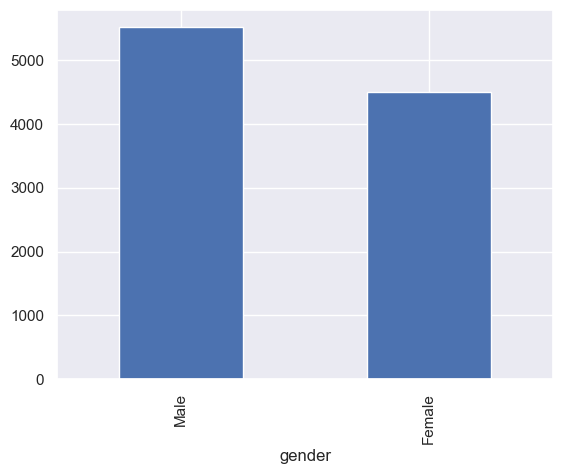

In [126]:
# 'line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin'
clean_dt['gender'].value_counts().plot(kind="bar")

<Axes: xlabel='education_level'>

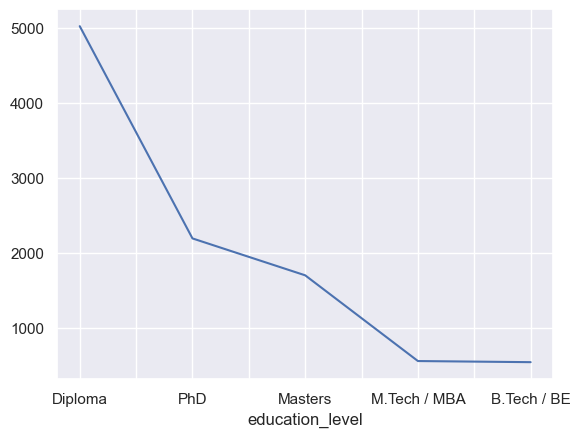

In [127]:
clean_dt['education_level'].value_counts().plot(kind="line")

<Axes: >

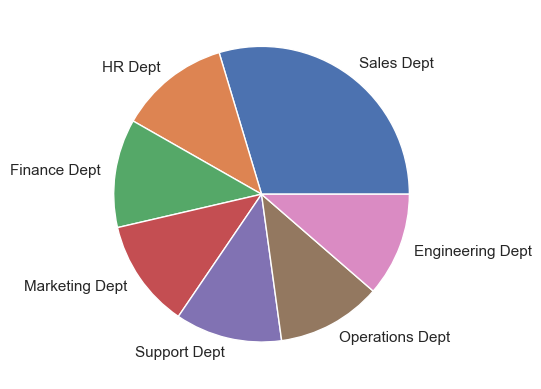

In [132]:
clean_dt['department'].value_counts().plot(kind="pie")

<Axes: ylabel='domain'>

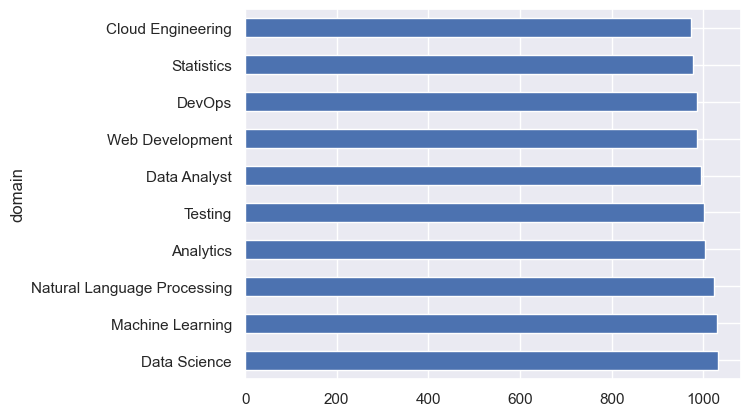

In [143]:
# 'line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin'

clean_dt['domain'].value_counts().plot(kind="barh")

In [144]:
clean_dt['salary'].quantile()

np.float64(5000.0)

In [145]:
clean_dt['salary'].quantile(0.50)

np.float64(5000.0)

In [146]:
clean_dt['salary'].quantile(0.25)

np.float64(60.0)

In [147]:
clean_dt['salary'].quantile(0.75)

np.float64(18000.0)

In [148]:
clean_dt['salary'].quantile(0.75) - clean_dt['salary'].quantile(0.25)

np.float64(17940.0)

In [149]:
clean_dt['salary'].skew()

np.float64(2.0316032609343604)

In [151]:
clean_dt['salary'].var()

np.float64(581334152.9915482)

In [152]:
clean_dt['salary'].std()

np.float64(24110.872091061912)

In [154]:
clean_dt['domain'].value_counts().to_frame()

,count
domain,
Data Science,1031
Machine Learning,1029
Natural Language Processing,1023
Analytics,1003
Testing,1001
Data Analyst,994
Web Development,987
DevOps,986
Statistics,978


In [155]:
clean_dt['gender'].value_counts().to_frame()

,count
gender,
Male,5509
Female,4497
